1


In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2
        ),
        "GB"
    )

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB


2

In [ ]:
!pip install -q -U transformers datasets sentencepiece sacrebleu accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 117.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.0/128.0 kB 14.6 MB/s eta 0:00:00


3

In [ ]:
import transformers
import datasets
import torch

print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("PyTorch:", torch.__version__)

Transformers: 5.15.1
Datasets: 5.0.1
PyTorch: 2.11.0+cu128


4

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


5

In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/Multilingual_Speech_Translator"
MODEL_DIR = os.path.join(PROJECT_DIR, "fine_tuned_marianmt_en_hi")
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("Project folder:", PROJECT_DIR)
print("Model folder:", MODEL_DIR)
print("Checkpoint folder:", CHECKPOINT_DIR)

Project folder: /content/drive/MyDrive/Multilingual_Speech_Translator
Model folder: /content/drive/MyDrive/Multilingual_Speech_Translator/fine_tuned_marianmt_en_hi
Checkpoint folder: /content/drive/MyDrive/Multilingual_Speech_Translator/checkpoints


6

In [ ]:
from datasets import load_dataset

dataset = load_dataset("cfilt/iitb-english-hindi")

print(dataset)

README.md:   0%|          | 0.00/3.14k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  190MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 85.7kB            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1659083 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/520 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2507 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['translation'],
        num_rows: 1659083
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 520
    })
    test: Dataset({
        features: ['translation'],
        num_rows: 2507
    })
})


7

In [ ]:
print(dataset["train"][0])



{'translation': {'en': 'Give your application an accessibility workout', 'hi': 'अपने अनुप्रयोग को पहुंचनीयता व्यायाम का लाभ दें'}}


8

In [ ]:
def is_not_empty(example):
    en = example["translation"]["en"].strip()
    hi = example["translation"]["hi"].strip()

    return len(en) > 0 and len(hi) > 0


train_clean = dataset["train"].filter(
    is_not_empty,
    num_proc=2
)

print("Original training samples:", len(dataset["train"]))
print("After removing empty pairs:", len(train_clean))
print("Removed:", len(dataset["train"]) - len(train_clean))

Filter (num_proc=2):   0%|          | 0/1659083 [00:00<?, ? examples/s]

Original training samples: 1659083
After removing empty pairs: 1652981
Removed: 6102


9

In [ ]:
def valid_length(example):
    en_words = len(example["translation"]["en"].split())
    hi_words = len(example["translation"]["hi"].split())

    return (
        3 <= en_words <= 100
        and
        3 <= hi_words <= 100
    )


train_clean = train_clean.filter(
    valid_length,
    num_proc=2
)

print("Training samples after length filtering:", len(train_clean))

Filter (num_proc=2):   0%|          | 0/1652981 [00:00<?, ? examples/s]

Training samples after length filtering: 1174640


10

In [ ]:
TRAIN_SIZE = 100_000

train_data = train_clean.select(
    range(TRAIN_SIZE)
)

print("Training samples:", len(train_data))
print("First example:")
print(train_data[0])

Training samples: 100000
First example:
{'translation': {'en': 'Give your application an accessibility workout', 'hi': 'अपने अनुप्रयोग को पहुंचनीयता व्यायाम का लाभ दें'}}


11


In [ ]:
from transformers import MarianMTModel, MarianTokenizer

MODEL_NAME = "Helsinki-NLP/opus-mt-en-hi"

tokenizer = MarianTokenizer.from_pretrained(MODEL_NAME)
model = MarianMTModel.from_pretrained(MODEL_NAME)

print("Model loaded successfully")
print("Model:", MODEL_NAME)

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/812k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.10M [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  306MB            

model.safetensors: downloading bytes:           |  0.00B            

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Model loaded successfully
Model: Helsinki-NLP/opus-mt-en-hi


12

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


13

In [ ]:
test_sentences = [
    "The weather is nice today.",
    "I am learning machine learning.",
    "This is a very important project.",
    "The students are working on a new technology."
]

model.eval()

for text in test_sentences:
    inputs = tokenizer(
        text,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_length=128,
            num_beams=4
        )

    translation = tokenizer.decode(
        output_ids[0],
        skip_special_tokens=True
    )

    print("English:", text)
    print("Hindi:", translation)
    print("-" * 60)

English: The weather is nice today.
Hindi: मौसम आज अच्छा है.
------------------------------------------------------------
English: I am learning machine learning.
Hindi: मैं मशीन सीखने के लिए सीख रहा हूँ.
------------------------------------------------------------
English: This is a very important project.
Hindi: यह एक बहुत ही महत्वपूर्ण परियोजना है.
------------------------------------------------------------
English: The students are working on a new technology.
Hindi: विद्यार्थी नयी तकनीक पर काम कर रहे हैं ।
------------------------------------------------------------


14

In [ ]:
MAX_LENGTH = 128

def preprocess_function(examples):
    inputs = [
        x["en"] for x in examples["translation"]
    ]

    targets = [
        x["hi"] for x in examples["translation"]
    ]

    model_inputs = tokenizer(
        inputs,
        max_length=MAX_LENGTH,
        truncation=True
    )

    labels = tokenizer(
        text_target=targets,
        max_length=MAX_LENGTH,
        truncation=True
    )

    model_inputs["labels"] = labels["input_ids"]

    return model_inputs

15

In [ ]:
tokenized_train = train_data.map(
    preprocess_function,
    batched=True,
    num_proc=2,
    remove_columns=["translation"]
)

print(tokenized_train)

Map (num_proc=2):   0%|          | 0/100000 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 100000
})


16

In [ ]:
tokenized_validation = dataset["validation"].map(
    preprocess_function,
    batched=True,
    num_proc=2,
    remove_columns=["translation"]
)

print(tokenized_validation)

Map (num_proc=2):   0%|          | 0/520 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 520
})


17

In [ ]:
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model
)

print("Data collator created successfully")

Data collator created successfully


18


In [ ]:
from transformers import Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    output_dir=CHECKPOINT_DIR,

    # Training
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    # Evaluation
    eval_strategy="epoch",

    # Saving
    save_strategy="epoch",
    save_total_limit=2,

    # Best model
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    # Performance
    fp16=True,

    # Logging
    logging_strategy="steps",
    logging_steps=100,

    # Other
    report_to="none",
    predict_with_generate=False
)

print("Training configuration created successfully")

Training configuration created successfully


19

In [ ]:
from transformers import Seq2SeqTrainer

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_validation,
    processing_class=tokenizer,
    data_collator=data_collator
)

print("Trainer created successfully")

Trainer created successfully


20

In [ ]:
print("Training examples:", len(trainer.train_dataset))
print("Validation examples:", len(trainer.eval_dataset))

Training examples: 100000
Validation examples: 520


21

In [ ]:
train_result = trainer.train()

print("Training completed successfully!")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Epoch,Training Loss,Validation Loss
1,0.395223,5.233306
2,0.190058,5.649178
3,0.142238,5.761491


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.encoder.embed_positions.weight', 'model.decoder.embed_tokens.weight', 'model.decoder.embed_positions.weight', 'lm_head.weight'].


Training completed successfully!


22

In [ ]:
import os

os.makedirs(MODEL_DIR, exist_ok=True)

trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

print("Best model saved successfully!")
print("Location:", MODEL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved successfully!
Location: /content/drive/MyDrive/Multilingual_Speech_Translator/fine_tuned_marianmt_en_hi


23

In [ ]:
import os

for root, dirs, files in os.walk(MODEL_DIR):
    print("\nFolder:", root)
    for file in files:
        print("  ", file)


Folder: /content/drive/MyDrive/Multilingual_Speech_Translator/fine_tuned_marianmt_en_hi
   config.json
   generation_config.json
   tokenizer_config.json
   vocab.json
   source.spm
   target.spm
   training_args.bin
   model.safetensors


24

In [ ]:
from transformers import MarianMTModel, MarianTokenizer

saved_tokenizer = MarianTokenizer.from_pretrained(MODEL_DIR)

saved_model = MarianMTModel.from_pretrained(MODEL_DIR)
saved_model = saved_model.to(device)
saved_model.eval()

print("Saved model loaded successfully!")
print("Device:", device)

/usr/local/lib/python3.13/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Saved model loaded successfully!
Device: cuda


25

In [ ]:
test_sentences = [
    "The weather is nice today.",
    "I am learning machine learning.",
    "This is a very important project.",
    "The students are working on a new technology."
]

for text in test_sentences:

    inputs = saved_tokenizer(
        text,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        output_ids = saved_model.generate(
            **inputs,
            max_length=128,
            num_beams=4
        )

    translation = saved_tokenizer.decode(
        output_ids[0],
        skip_special_tokens=True
    )

    print("English:", text)
    print("Hindi:", translation)
    print("-" * 60)

English: The weather is nice today.
Hindi: मौसम अच्छा है.
------------------------------------------------------------
English: I am learning machine learning.
Hindi: मैं मशीन का अभ्यास कर रहा हूँ.
------------------------------------------------------------
English: This is a very important project.
Hindi: यह एक बहुत ही महत्वपूर्ण परियोजना है.
------------------------------------------------------------
English: The students are working on a new technology.
Hindi: बच्चे नयी तकनीक पर काम कर रहे हैं.
------------------------------------------------------------


26

In [ ]:
import sacrebleu
from tqdm.auto import tqdm

predictions = []
references = []

saved_model.eval()

for example in tqdm(dataset["test"]):

    english = example["translation"]["en"]
    hindi = example["translation"]["hi"]

    inputs = saved_tokenizer(
        english,
        return_tensors="pt",
        truncation=True,
        max_length=128
    ).to(device)

    with torch.no_grad():
        output_ids = saved_model.generate(
            **inputs,
            max_length=128,
            num_beams=4
        )

    prediction = saved_tokenizer.decode(
        output_ids[0],
        skip_special_tokens=True
    )

    predictions.append(prediction)
    references.append(hindi)

bleu = sacrebleu.corpus_bleu(
    predictions,
    [references]
)

print("Fine-tuned BLEU:", bleu.score)

  0%|          | 0/2507 [00:00<?, ?it/s]

Fine-tuned BLEU: 6.042647203432427


27

In [ ]:
pretrained_predictions = []
test_references = []

model.eval()

for example in tqdm(dataset["test"]):

    english = example["translation"]["en"]
    hindi = example["translation"]["hi"]

    inputs = tokenizer(
        english,
        return_tensors="pt",
        truncation=True,
        max_length=128
    ).to(device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_length=128,
            num_beams=4
        )

    prediction = tokenizer.decode(
        output_ids[0],
        skip_special_tokens=True
    )

    pretrained_predictions.append(prediction)
    test_references.append(hindi)

pretrained_bleu = sacrebleu.corpus_bleu(
    pretrained_predictions,
    [test_references]
)

print("Pretrained BLEU:", pretrained_bleu.score)

  0%|          | 0/2507 [00:00<?, ?it/s]

Pretrained BLEU: 6.04086909710524


# Experiment 2

28

In [ ]:
def is_empty(example):
    en = example["translation"]["en"].strip()
    hi = example["translation"]["hi"].strip()

    return len(en) == 0 or len(hi) == 0


train_clean = dataset["train"].filter(
    lambda x: not is_empty(x),
    num_proc=2
)

print("Original training samples:", len(dataset["train"]))
print("After removing empty pairs:", len(train_clean))
print("Removed:", len(dataset["train"]) - len(train_clean))

Filter (num_proc=2):   0%|          | 0/1659083 [00:00<?, ? examples/s]

Original training samples: 1659083
After removing empty pairs: 1652981
Removed: 6102


29

In [ ]:
def valid_length(example):
    en_words = len(example["translation"]["en"].split())
    hi_words = len(example["translation"]["hi"].split())

    return (
        3 <= en_words <= 100
        and
        3 <= hi_words <= 100
    )


train_clean = train_clean.filter(
    valid_length,
    num_proc=2
)

print("Training samples after length filtering:", len(train_clean))

Filter (num_proc=2):   0%|          | 0/1652981 [00:00<?, ? examples/s]

Training samples after length filtering: 1174640


30

In [ ]:
SEED = 42
TRAIN_SIZE = 100_000

train_data_exp2 = train_clean.shuffle(seed=SEED).select(
    range(TRAIN_SIZE)
)

print("Experiment 2 training samples:", len(train_data_exp2))
print("First random training example:")
print(train_data_exp2[0])

Experiment 2 training samples: 100000
First random training example:
{'translation': {'en': 'Our gaze is turned to the future.', 'hi': 'हम भविष्य की आरे देख रहे हैं। '}}


31

In [ ]:
from transformers import MarianTokenizer

BASE_MODEL_NAME = "Helsinki-NLP/opus-mt-en-hi"

tokenizer = MarianTokenizer.from_pretrained(BASE_MODEL_NAME)

def preprocess_function(examples):

    inputs = [
        item["en"]
        for item in examples["translation"]
    ]

    targets = [
        item["hi"]
        for item in examples["translation"]
    ]

    model_inputs = tokenizer(
        inputs,
        max_length=128,
        truncation=True
    )

    labels = tokenizer(
        text_target=targets,
        max_length=128,
        truncation=True
    )

    model_inputs["labels"] = labels["input_ids"]

    return model_inputs

print("Tokenizer and preprocessing function ready!")

Tokenizer and preprocessing function ready!


/usr/local/lib/python3.13/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


32

In [ ]:
tokenized_train_exp2 = train_data_exp2.map(
    preprocess_function,
    batched=True,
    num_proc=2,
    remove_columns=["translation"]
)

print(tokenized_train_exp2)

Map (num_proc=2):   0%|          | 0/100000 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 100000
})


33

In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/Multilingual_Speech_Translator"

EXP2_CHECKPOINT_DIR = os.path.join(
    PROJECT_DIR,
    "experiment_2_final_checkpoints"
)

EXP2_MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "experiment_2_final"
)

os.makedirs(EXP2_CHECKPOINT_DIR, exist_ok=True)
os.makedirs(EXP2_MODEL_DIR, exist_ok=True)

print("Experiment 2 folders created")
print("Checkpoint:", EXP2_CHECKPOINT_DIR)
print("Model:", EXP2_MODEL_DIR)

Experiment 2 folders created
Checkpoint: /content/drive/MyDrive/Multilingual_Speech_Translator/experiment_2_final_checkpoints
Model: /content/drive/MyDrive/Multilingual_Speech_Translator/experiment_2_final


34

In [ ]:
from transformers import MarianMTModel

MODEL_NAME = "Helsinki-NLP/opus-mt-en-hi"

model_exp2 = MarianMTModel.from_pretrained(MODEL_NAME)

model_exp2 = model_exp2.to(device)

print("Experiment 2 model loaded successfully")
print("Device:", device)

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

Experiment 2 model loaded successfully
Device: cuda


35

In [ ]:
from transformers import Seq2SeqTrainingArguments

EXP2_CHECKPOINT_DIR = "/content/drive/MyDrive/Multilingual_Speech_Translator/experiment_2_final_checkpoints"
EXP2_MODEL_DIR = "/content/drive/MyDrive/Multilingual_Speech_Translator/experiment_2_final"

training_args_exp2 = Seq2SeqTrainingArguments(
    output_dir=EXP2_CHECKPOINT_DIR,

    # Training
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    # Evaluation and saving
    eval_strategy="epoch",
    save_strategy="epoch",

    # Best model
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    # Speed
    fp16=True,

    # Logging
    logging_steps=100,

    # Checkpoints
    save_total_limit=2,

    # Reproducibility
    seed=42,

    report_to="none"
)

print("Experiment 2 training configuration created successfully")
print("Checkpoint folder:", EXP2_CHECKPOINT_DIR)
print("Final model folder:", EXP2_MODEL_DIR)

Experiment 2 training configuration created successfully
Checkpoint folder: /content/drive/MyDrive/Multilingual_Speech_Translator/experiment_2_final_checkpoints
Final model folder: /content/drive/MyDrive/Multilingual_Speech_Translator/experiment_2_final


36

In [ ]:
tokenized_validation = dataset["validation"].map(
    preprocess_function,
    batched=True,
    num_proc=2,
    remove_columns=["translation"]
)

print(tokenized_validation)

Map (num_proc=2):   0%|          | 0/520 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 520
})


37

In [ ]:
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model_exp2
)

print("Data collator created successfully")

Data collator created successfully


38

In [ ]:
from transformers import Seq2SeqTrainer

trainer_exp2 = Seq2SeqTrainer(
    model=model_exp2,
    args=training_args_exp2,
    train_dataset=tokenized_train_exp2,
    eval_dataset=tokenized_validation,
    processing_class=tokenizer,
    data_collator=data_collator
)

print("Experiment 2 trainer created successfully")
print("Training examples:", len(tokenized_train_exp2))
print("Validation examples:", len(tokenized_validation))

Experiment 2 trainer created successfully
Training examples: 100000
Validation examples: 520


39

In [ ]:
import os

print("Checkpoint folder exists:", os.path.exists(EXP2_CHECKPOINT_DIR))
print("Final model folder exists:", os.path.exists(EXP2_MODEL_DIR))

print("\nCheckpoint path:")
print(EXP2_CHECKPOINT_DIR)

print("\nFinal model path:")
print(EXP2_MODEL_DIR)

Checkpoint folder exists: True
Final model folder exists: True

Checkpoint path:
/content/drive/MyDrive/Multilingual_Speech_Translator/experiment_2_final_checkpoints

Final model path:
/content/drive/MyDrive/Multilingual_Speech_Translator/experiment_2_final


40

In [ ]:
train_result_exp2 = trainer_exp2.train()

print("Experiment 2 training completed successfully!")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss
1,2.669098,3.416514
2,2.069561,3.251223
3,1.841324,3.226765


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.encoder.embed_positions.weight', 'model.decoder.embed_tokens.weight', 'model.decoder.embed_positions.weight', 'lm_head.weight'].


Experiment 2 training completed successfully!


41

In [ ]:
import os

EXP2_MODEL_DIR = "/content/drive/MyDrive/Multilingual_Speech_Translator/experiment_2_final"

os.makedirs(EXP2_MODEL_DIR, exist_ok=True)

# Save final model
trainer_exp2.save_model(EXP2_MODEL_DIR)

# Save tokenizer
tokenizer.save_pretrained(EXP2_MODEL_DIR)

print("Experiment 2 final model saved!")
print("Path:", EXP2_MODEL_DIR)

print("\nFiles:")
for file in os.listdir(EXP2_MODEL_DIR):
    print("-", file)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Experiment 2 final model saved!
Path: /content/drive/MyDrive/Multilingual_Speech_Translator/experiment_2_final

Files:
- config.json
- generation_config.json
- model.safetensors
- tokenizer_config.json
- vocab.json
- source.spm
- target.spm
- training_args.bin


42

In [ ]:
import os

EXP2_MODEL_DIR = "/content/drive/MyDrive/Multilingual_Speech_Translator/experiment_2_final"

print("Final model folder exists:", os.path.exists(EXP2_MODEL_DIR))
print("\nFiles in final model folder:")

for file in os.listdir(EXP2_MODEL_DIR):
    print("-", file)

Final model folder exists: True

Files in final model folder:
- config.json
- generation_config.json
- model.safetensors
- tokenizer_config.json
- vocab.json
- source.spm
- target.spm
- training_args.bin


43

In [ ]:
from transformers import MarianTokenizer, MarianMTModel

EXP2_MODEL_DIR = "/content/drive/MyDrive/Multilingual_Speech_Translator/experiment_2_final"

tokenizer_exp2 = MarianTokenizer.from_pretrained(EXP2_MODEL_DIR)

model_exp2 = MarianMTModel.from_pretrained(EXP2_MODEL_DIR)

model_exp2 = model_exp2.to(device)
model_exp2.eval()

print("Experiment 2 final model loaded successfully!")
print("Device:", device)

/usr/local/lib/python3.13/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Experiment 2 final model loaded successfully!
Device: cuda


44

In [ ]:
import sacrebleu
from tqdm import tqdm

model_exp2.eval()

predictions_exp2 = []
references_exp2 = []

test_data = dataset["test"]

for example in tqdm(test_data):

    english = example["translation"]["en"]
    hindi = example["translation"]["hi"]

    inputs = tokenizer_exp2(
        english,
        return_tensors="pt",
        truncation=True,
        max_length=128
    ).to(device)

    with torch.no_grad():
        output_ids = model_exp2.generate(
            **inputs,
            max_length=128,
            num_beams=4
        )

    prediction = tokenizer_exp2.decode(
        output_ids[0],
        skip_special_tokens=True
    )

    predictions_exp2.append(prediction)
    references_exp2.append(hindi)

bleu_exp2 = sacrebleu.corpus_bleu(
    predictions_exp2,
    [references_exp2]
)

print("Experiment 2 BLEU:", bleu_exp2.score)

100%|██████████| 2507/2507 [11:05<00:00,  3.77it/s]


Experiment 2 BLEU: 13.25998507408897


45

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Current clean-run BLEU scores
pretrained_bleu = 6.04086909710524
experiment_2_bleu = 13.25998507408897

# Enter your CURRENT Experiment 1 BLEU score here
experiment_1_bleu = 5.787175490160719

results = pd.DataFrame({
    "Model": [
        "Pretrained MarianMT",
        "Experiment 1",
        "Experiment 2"
    ],
    "BLEU": [
        pretrained_bleu,
        experiment_1_bleu,
        experiment_2_bleu
    ]
})

print(results)

                 Model       BLEU
0  Pretrained MarianMT   6.040869
1         Experiment 1   5.787175
2         Experiment 2  13.259985


46

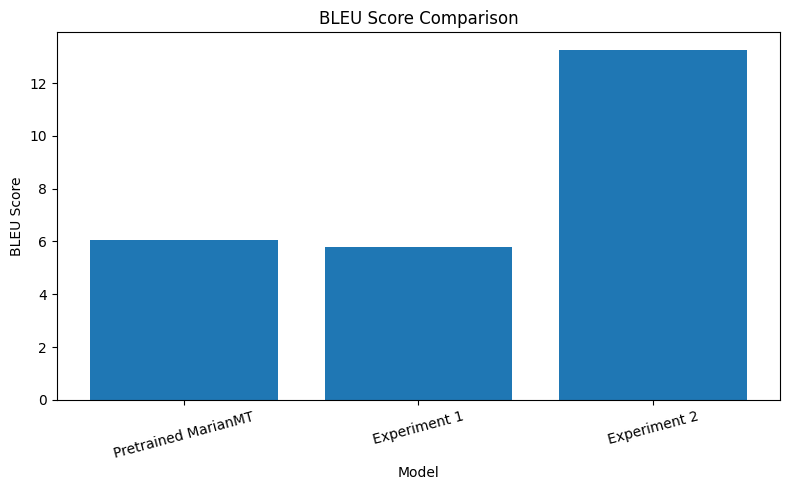

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["BLEU"])

plt.ylabel("BLEU Score")
plt.xlabel("Model")
plt.title("BLEU Score Comparison")

plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

In [ ]:
from transformers import MarianMTModel, MarianTokenizer

BASE_MODEL_NAME = "Helsinki-NLP/opus-mt-en-hi"

pretrained_tokenizer = MarianTokenizer.from_pretrained(
    BASE_MODEL_NAME
)

pretrained_model = MarianMTModel.from_pretrained(
    BASE_MODEL_NAME
)

pretrained_model = pretrained_model.to(device)
pretrained_model.eval()

print("Pretrained model loaded successfully!")
print("Device:", device)

/usr/local/lib/python3.13/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

Pretrained model loaded successfully!
Device: cuda


In [ ]:
test_examples = [
    "The weather is nice today.",
    "I am learning machine learning.",
    "This is a very important project.",
    "The students are working on a new technology.",
    "We are going to the university tomorrow."
]

for sentence in test_examples:

    # Pretrained model
    inputs_pre = pretrained_tokenizer(
        sentence,
        return_tensors="pt",
        truncation=True,
        max_length=128
    ).to(device)

    with torch.no_grad():
        output_pre = pretrained_model.generate(
            **inputs_pre,
            max_length=128,
            num_beams=4
        )

    translation_pre = pretrained_tokenizer.decode(
        output_pre[0],
        skip_special_tokens=True
    )

    # Experiment 2
    inputs_exp2 = tokenizer_exp2(
        sentence,
        return_tensors="pt",
        truncation=True,
        max_length=128
    ).to(device)

    with torch.no_grad():
        output_exp2 = model_exp2.generate(
            **inputs_exp2,
            max_length=128,
            num_beams=4
        )

    translation_exp2 = tokenizer_exp2.decode(
        output_exp2[0],
        skip_special_tokens=True
    )

    print("=" * 80)
    print("English      :", sentence)
    print("Pretrained   :", translation_pre)
    print("Experiment 2 :", translation_exp2)

English      : The weather is nice today.
Pretrained   : मौसम आज अच्छा है.
Experiment 2 : मौसम आज अच्छा है।
English      : I am learning machine learning.
Pretrained   : मैं मशीन सीखने के लिए सीख रहा हूँ.
Experiment 2 : मैं मशीन सीखने वाली सीख रही हूं।
English      : This is a very important project.
Pretrained   : यह एक बहुत ही महत्वपूर्ण परियोजना है.
Experiment 2 : यह एक बहुत महत्वपूर्ण परियोजना है।
English      : The students are working on a new technology.
Pretrained   : विद्यार्थी नयी तकनीक पर काम कर रहे हैं ।
Experiment 2 : विद्यार्थी एक नई तकनीक पर काम कर रहे हैं।
English      : We are going to the university tomorrow.
Pretrained   : हम कल विश्‍वविद्यालय जा रहे हैं.
Experiment 2 : हम कल विश्वविद्यालय में जा रहे हैं।


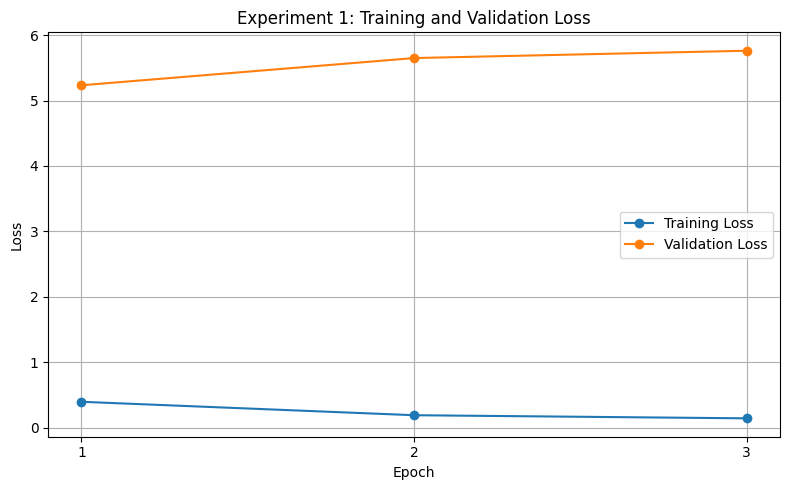

In [ ]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3]

# Experiment 1
exp1_train_loss = [0.395223, 0.190058, 0.142238]
exp1_val_loss = [5.233306, 5.649178, 5.761491]

plt.figure(figsize=(8, 5))
plt.plot(epochs, exp1_train_loss, marker="o", label="Training Loss")
plt.plot(epochs, exp1_val_loss, marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 1: Training and Validation Loss")
plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

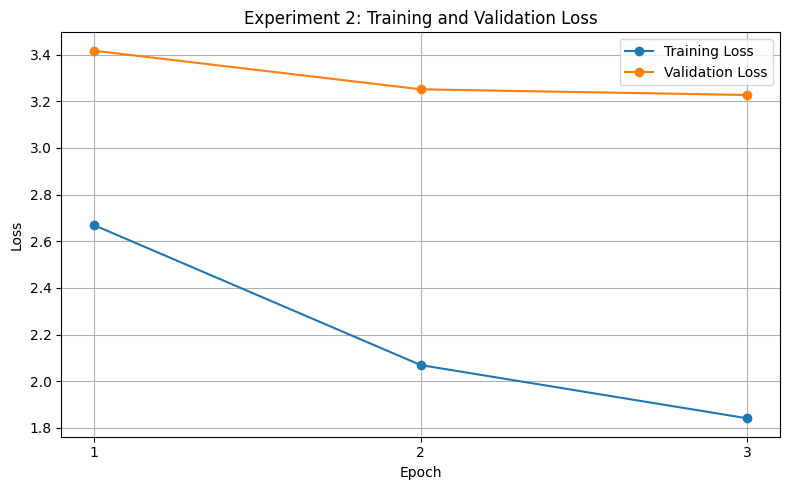

In [ ]:
# Experiment 2
exp2_train_loss = [2.669098, 2.069561, 1.841324]
exp2_val_loss = [3.416514, 3.251223, 3.226765]

plt.figure(figsize=(8, 5))
plt.plot(epochs, exp2_train_loss, marker="o", label="Training Loss")
plt.plot(epochs, exp2_val_loss, marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 2: Training and Validation Loss")
plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

final_results = pd.DataFrame({
    "Model": [
        "Pretrained MarianMT",
        "Experiment 1",
        "Experiment 2"
    ],
    "BLEU Score": [
        6.04086909710524,
        5.787175490160719,
        13.25998507408897
    ]
})

final_results["Improvement over Pretrained (%)"] = (
    (final_results["BLEU Score"] - final_results.loc[0, "BLEU Score"])
    / final_results.loc[0, "BLEU Score"] * 100
)

final_results

,Model,BLEU Score,Improvement over Pretrained (%)
0,Pretrained MarianMT,6.040869,0.000000
1,Experiment 1,5.787175,-4.199621
2,Experiment 2,13.259985,119.504592
